¿Cómo se convierte una columna a fecha con pd.to_datetime()?

df["columna"] = pd.to_datetime(df["columna"])


¿Qué pasa si tienes fecha y hora en columnas separadas? ¿Cómo las combinas en un solo datetime?
Primero me aseguro de que ambas sean fechas y después "sumar" ambas columnas en una sola



¿Qué hace el parámetro errors='coerce' en pd.to_datetime()?
Si no hay valores o estos están en un formatio inválido los rellena con un valor vacío

In [ ]:
import pandas as pd
hechos = pd.read_excel("siniestros_viales_hechos.xlsx")
victimas = pd.read_excel("siniestros_viales_victimas.xlsx")

print(hechos.shape, victimas.shape)

(65818, 21) (75193, 9)


In [ ]:
#Revisar si las columnas fecha y hora tienen elformato necesario
print(hechos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65818 entries, 0 to 65817
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   id_siniestro                      65818 non-null  object
 1   numero_total_de_victimas          65818 non-null  object
 2   numero_victimas_leve_siniestro    65818 non-null  int64 
 3   numero_victimas_grave_siniestro   65818 non-null  int64 
 4   numero_victimas_mortal_siniestro  65818 non-null  int64 
 5   fecha_siniestro                   65818 non-null  object
 6   anio_siniestro                    65818 non-null  int64 
 7   mes_siniestro                     65818 non-null  int64 
 8   dia_siniestro                     65818 non-null  int64 
 9   hora_siniestro                    65741 non-null  object
 10  rango_horario                     65741 non-null  object
 11  direccion_normalizada_siniestro   52918 non-null  object
 12  comuna_siniestro  

In [ ]:
#Revisar si hay valores nulos especificamente en la columna de fecha y hora
print(hechos.isnull().sum())

id_siniestro                            0
numero_total_de_victimas                0
numero_victimas_leve_siniestro          0
numero_victimas_grave_siniestro         0
numero_victimas_mortal_siniestro        0
fecha_siniestro                         0
anio_siniestro                          0
mes_siniestro                           0
dia_siniestro                           0
hora_siniestro                         77
rango_horario                          77
direccion_normalizada_siniestro     12900
comuna_siniestro                     3017
tipo_de_via_siniestro               12227
geocodificacion_plana                2367
longitud_siniestro                   2379
latitud_siniestro                    2379
participantes_siniestro                 1
modo_desplazamiento_victima             1
contraparte_siniestro                   1
gravedad_siniestro                      0
dtype: int64


In [ ]:
#Verificar si la fecha estámal escrita a pesar del formato
hechos["fecha_siniestro"].head()

,fecha_siniestro
0,2019-01-01
1,2019-01-01
2,2019-01-01
3,2019-01-01
4,2019-01-01


In [ ]:
#Convertir objeto a fecha
hechos["fecha_siniestro"]= pd.to_datetime(hechos["fecha_siniestro"], errors='coerce')
print(hechos["fecha_siniestro"].isnull().sum())
print(hechos["fecha_siniestro"].dtype)

0
datetime64[ns]


In [ ]:
#Sumar fecha y la hora
hechos["fecha_hora"] =pd.to_datetime(hechos["fecha_siniestro"].astype(str) + " " + hechos["hora_siniestro"].astype(str), errors='coerce')

print(hechos["fecha_hora"].isnull().sum())
print(hechos["fecha_hora"].dtype)
print(hechos[["fecha_hora","fecha_siniestro","hora_siniestro"]])

81
datetime64[ns]
               fecha_hora fecha_siniestro hora_siniestro
0     2019-01-01 01:55:00      2019-01-01       01:55:00
1     2019-01-01 18:50:00      2019-01-01       18:50:00
2     2019-01-01 13:40:00      2019-01-01       13:40:00
3     2019-01-01 07:15:00      2019-01-01       07:15:00
4     2019-01-01 12:24:00      2019-01-01       12:24:00
...                   ...             ...            ...
65813 2025-09-09 08:00:00      2025-09-09       08:00:00
65814 2025-09-09 07:59:00      2025-09-09       07:59:00
65815 2025-09-09 17:26:00      2025-09-09       17:26:00
65816 2025-09-09 07:40:00      2025-09-09       07:40:00
65817 2025-09-09 17:57:00      2025-09-09       17:57:00

[65818 rows x 3 columns]


Decisión N-1 #1: No se imputan las 81 filas sin fecha_hora válida. Se conservan en el DataFrame con NaT, y se excluyen únicamente cuando se analice por hora. Se documentará en el informe como limitación ("0.12% de hechos sin hora registrada").

Crea las columnas temporales (si aún no las tienes):

año, mes, dia_semana, hora_del_dia

In [ ]:
hechos["col_año"] = hechos["fecha_hora"].dt.year
hechos["col_mes"] = hechos["fecha_hora"].dt.month
hechos["col_dia"] = hechos["fecha_hora"].dt.dayofweek
hechos["col_hora"] = hechos["fecha_hora"].dt.hour

Genera esta visualización:

Un histograma de hora_del_dia (24 barras, de 0 a 23).

Título claro: "Distribución de siniestros viales por hora del día".

Eje X etiquetado: "Hora del día (0-23)".

Eje Y: "Número de hechos".

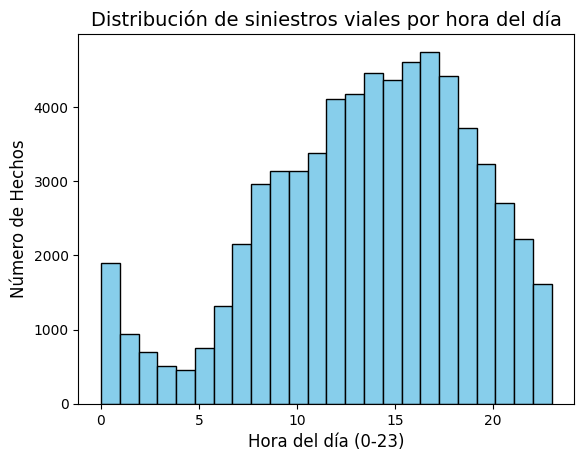

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(hechos["col_hora"], bins=24, color='skyblue',edgecolor ='black')
plt.title("Distribución de siniestros viales por hora del día", fontsize=14)
plt.xlabel("Hora del día (0-23)", fontsize=12)
plt.ylabel("Número de Hechos", fontsize=12)
plt.show()

Cuéntame qué observas:

¿Hay horas pico claras?
Sí de las 15-18 horas

¿Hay horas "valle"?
Sí en la madrugada desde las 0 hastas las 7 a.m.

¿Coincide con lo que esperabas intuitivamente (hora pico mañana, noche)?
Al reves

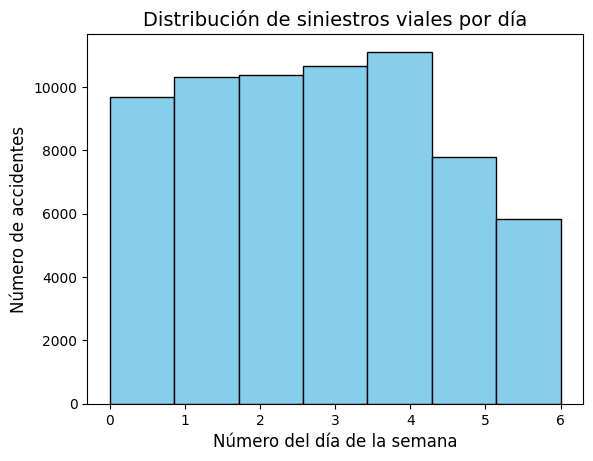

In [ ]:
#Histograma por días de la semana
plt.hist(hechos["col_dia"], bins=7, color='skyblue', edgecolor='black')
plt.title("Distribución de siniestros viales por día", fontsize=14)
plt.xlabel("Número del día de la semana", fontsize=12)
plt.ylabel("Número de accidentes", fontsize=12)
plt.show()

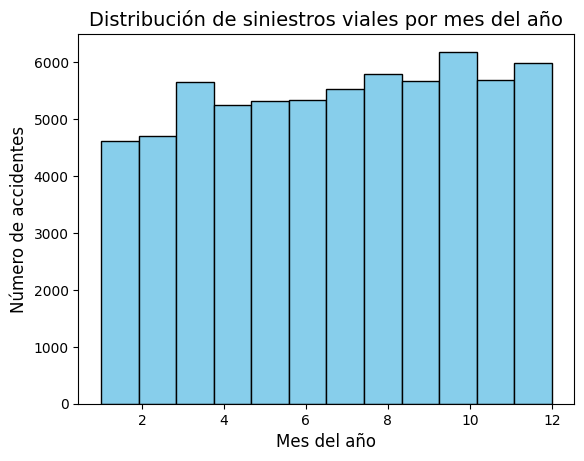

In [ ]:
#Histograma por mes del año
plt.hist(hechos["col_mes"], bins=12, color='skyblue', edgecolor='black')
plt.title("Distribución de siniestros viales por mes del año", fontsize=14)
plt.xlabel("Mes del año", fontsize=12)
plt.ylabel("Número de accidentes", fontsize=12)
plt.show()

In [ ]:
#Saber exactamente los accidentes por hora
print(hechos["col_hora"].value_counts().sort_index())

col_hora
0.0     1901
1.0      947
2.0      693
3.0      508
4.0      454
5.0      754
6.0     1317
7.0     2150
8.0     2960
9.0     3141
10.0    3134
11.0    3384
12.0    4116
13.0    4181
14.0    4458
15.0    4361
16.0    4610
17.0    4748
18.0    4421
19.0    3719
20.0    3231
21.0    2708
22.0    2224
23.0    1617
Name: count, dtype: int64


In [ ]:
#Verificar complitud de años y ver días
# ¿Cuántos hechos por año?
print(hechos['col_año'].value_counts().sort_index())

# ¿Qué rango de fechas cubre el dataset?
print(hechos['fecha_hora'].min(), hechos['fecha_hora'].max())

# Cruce: año vs mes (para ver si todos los años tienen todos los meses)
print(hechos.groupby(['col_año', 'col_mes']).size().unstack())

col_año
2019.0    10151
2020.0     6061
2021.0     7812
2022.0     9531
2023.0     9910
2024.0    10524
2025.0    11748
Name: count, dtype: int64
2019-01-01 01:55:00 2025-12-31 19:37:00
col_mes  1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  11.0  \
col_año                                                                     
2019.0    750   800   960   967  1049   896   937   912   895   891   554   
2020.0    679   728   493   194   328   325   359   442   497   585   690   
2021.0    533   484   717   608   300   674   701   806   661   833   660   
2022.0    563   628   867   851   827   832   762   828   901   847   831   
2023.0    609   606   875   807   906   856   865   864   869   907   882   
2024.0    710   714   823   824   915   778   895   917   898   999   971   
2025.0    782   740   915   997   990   977  1009  1021   957  1125  1097   

col_mes  12.0  
col_año        
2019.0    540  
2020.0    741  
2021.0    835  
2022.0    794  
2023.0    864  
2024.0  

In [ ]:
#Ver cómo se desglosa los accidentes por día
print(hechos["col_dia"].value_counts().sort_index())

col_dia
0.0     9665
1.0    10306
2.0    10376
3.0    10667
4.0    11109
5.0     7779
6.0     5835
Name: count, dtype: int64


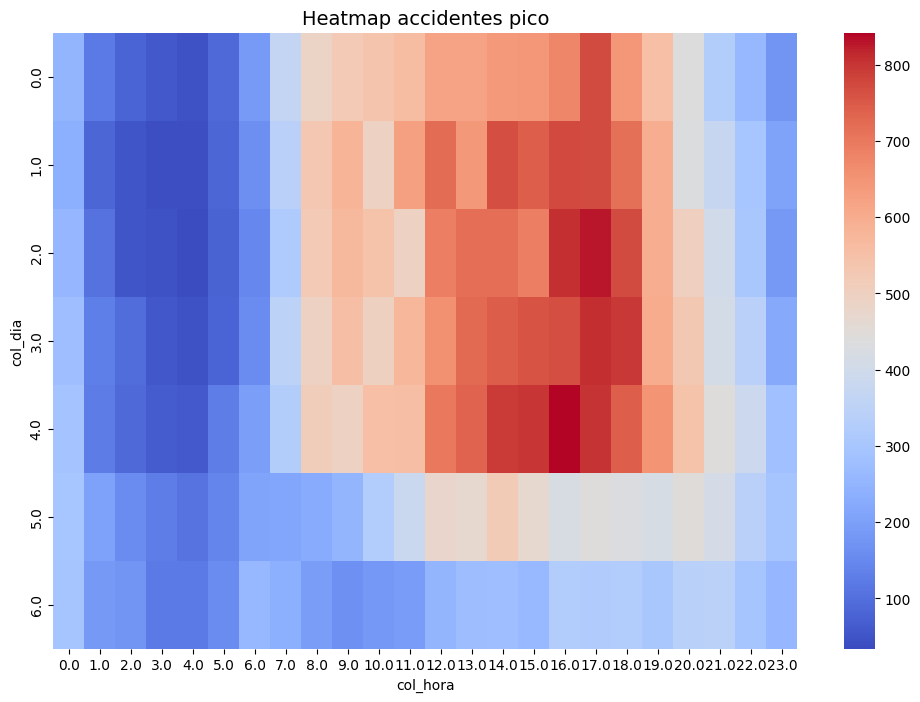

In [ ]:
#Cruzar los datos más altos de día y fecha
import seaborn as sns
acc_pic = pd.crosstab(hechos["col_dia"], hechos["col_hora"])
plt.figure(figsize=(12,8))
sns.heatmap(acc_pic, annot=False, cmap='coolwarm')
plt.title("Heatmap accidentes pico", fontsize=14)
plt.show()

/tmp/ipykernel_1725/1893599992.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hechos[hechos['col_año'] != 2020].set_index('fecha_hora').resample('M').size().plot(figsize=(14,6))


<Axes: xlabel='fecha_hora'>

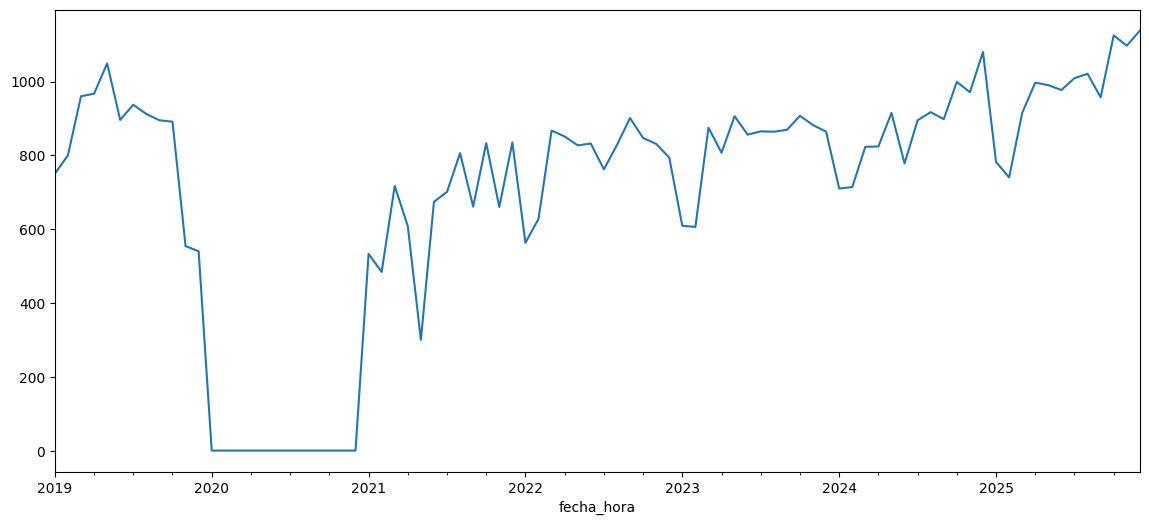

In [ ]:
hechos[hechos['col_año'] != 2020].set_index('fecha_hora').resample('M').size().plot(figsize=(14,6))

La tendencia es similar aprox. 800 accidentes al mes.Sin embargo, sí hay una clara tendencia alcista en los últimos años.

In [ ]:
#Comprobar que los 800 son mensuales o anuales
hechos[hechos["col_año"] != 2020].groupby("col_año").size()

,0
col_año,
2019.0,10151
2021.0,7812
2022.0,9531
2023.0,9910
2024.0,10524
2025.0,11748


# Ubicación

Dónde ocurren los accidentes

In [ ]:
#Identificar las columnas de ubicación
print(hechos[["direccion_normalizada_siniestro","comuna_siniestro","geocodificacion_plana","longitud_siniestro","latitud_siniestro","tipo_de_via_siniestro"]].isnull().sum())

direccion_normalizada_siniestro    12900
comuna_siniestro                    3017
geocodificacion_plana               2367
longitud_siniestro                  2379
latitud_siniestro                   2379
tipo_de_via_siniestro              12227
dtype: int64


In [ ]:
print(hechos[hechos['comuna_siniestro'].isnull() & hechos['latitud_siniestro'].isnull()].shape)
print(hechos[hechos['comuna_siniestro'].isnull() & hechos['latitud_siniestro'].notnull()].shape)

(2166, 26)
(851, 26)


## Verificación: ¿los hechos sin ubicación se concentran en algún año?

Antes de construir mapas geográficos, necesitamos saber si la falta de
coordenadas es aleatoria o sistemática. Si los hechos sin ubicación se
concentran en años específicos, el mapa de esos años estará sesgado y no
será comparable con otros.

**Decisión previa:** trabajaremos el análisis geográfico separando por año
(Opción C) para evitar que un año con mejor registro opaque a los demás.

In [ ]:
#Los 2166 son accidentes sin ubicacion y los 851 son accidentes sin comuna pero con coordenadas. Antes de decidir si usar los valores de comuna o de geolocalización, debemos averiguar como los valores faltantes se dispersan a lo largo del estudio
vacios = (hechos[hechos["latitud_siniestro"].isnull()])
vacios["col_año"].value_counts().sort_index()

,count
col_año,
2019.0,530
2020.0,201
2021.0,510
2022.0,393
2023.0,271
2024.0,444
2025.0,1


## Hallazgo

- 2025 tiene solo 1 hecho sin ubicación → el sistema de registro mejoró
  drásticamente ese año.
- 2019-2024 tienen entre 200 y 530 hechos sin ubicación por año.
- **Implicación:** el análisis geográfico no es comparable entre años sin
  separar por año. Los mapas de 2019-2024 están incompletos; el de 2025
  es el más confiable geográficamente.

## Pregunta. El año más conflictivo(2019) tiene comuna registrada?


Antes de decidir cómo tratar los nulos geográficos, verificamos si en 2019
(el año con más hechos sin ubicación: 530) los nulos están "encadenados".
Es decir: si un hecho no tiene latitud, ¿tampoco tiene comuna?

Si los nulos están encadenados, significa que para ese subconjunto no
tenemos ninguna información geográfica y no podemos ubicarlos ni por barrio.
Si tienen comuna pero no latitud, podemos al menos mapearlos por comuna.

Este paso es de muestreo por caso extremo: si el año más problemático está
limpio, los demás también lo estarán probablemente.

In [ ]:
#Revisar si en 2019 los valores nulos sin latitud tampoco tienen comuna?
#1.- Del df obtener solo las columnas que nos interesan
geo = hechos[["col_año","latitud_siniestro","comuna_siniestro"]]
#2.- Filtrar por año
geo_2019 = (geo[geo["col_año"]==2019])
#3.- Quedarse con los registros que tienen valores nulos
geo_2019_v = (geo_2019[geo_2019["latitud_siniestro"].isnull()])
#4- Sobre ese subconjunto, contar cuántas filas tienen comuna_siniestro nula vs no nula
com_vacio = geo_2019_v[geo_2019_v["comuna_siniestro"].isnull()]
com_novacio= geo_2019_v[geo_2019_v["comuna_siniestro"].notnull()]
print(f"El número de registro nulos en comuna es: {com_vacio.shape[0]}. Los registros cpon valores son: {com_novacio.shape[0]}. Y el total de registros con latitud vacio en 2019 es: {len(geo_2019_v)}")

El número de registro nulos en comuna es: 442. Los registros cpon valores son: 88. Y el total de registros con latitud vacio en 2019 es: 530


## Hallazgo: nulos geográficos encadenados en 2019

De los 530 hechos sin latitud en 2019:
- 442 (83.4%) tampoco tienen comuna → sin información geográfica alguna.
- 88 (16.6%) tienen comuna → recuperables parcialmente.

**Implicación:** el análisis geográfico pierde ~442 hechos en 2019
(0.67% del total anual). No podemos saber si el sesgo es aleatorio,
pero es una limitación menor y debe documentarse.

## Análisis geográfico: distribución de hechos por comuna

Habiendo cerrado la dimensión temporal, pasamos a la pregunta "¿DÓNDE
ocurren los siniestros?". La primera aproximación es contar cuántos hechos
hay por comuna, para identificar las zonas de mayor concentración.

**Consideraciones previas:**
- Los hechos sin comuna (3.017 registros, 4.6%) se excluirán de este conteo.
  Ya verificamos en 2019 que la mayoría de esos nulos están encadenados
  (sin comuna y sin latitud), por lo que no son recuperables.
- Este conteo es "número absoluto de hechos". No está normalizado por
  población, extensión o tráfico de cada comuna. Una comuna con más hechos
  no necesariamente es "más peligrosa": puede simplemente tener más
  circulación. La normalización queda fuera del alcance de este dataset.

In [ ]:
#OBJETIVO: contar cuántos hechos hay por comuna, ordenados de mayor a menor, para identificar las zonas de mayor concentración.
hechos_com =(hechos["comuna_siniestro"].astype(str).value_counts().sort_index())
print(hechos_com)

comuna_siniestro
1            1400
10            643
11            534
12            687
13            716
14            848
15            852
2             415
3             861
4             842
5             666
6             517
7             831
8             608
9             797
COMUNA 1       51
COMUNA 15       1
COMUNA 3        3
Comuna 1     5790
Comuna 10    3133
Comuna 11    2997
Comuna 12    3623
Comuna 13    3249
Comuna 14    3648
Comuna 15    4361
Comuna 2     1935
Comuna 3     3994
Comuna 4     3720
Comuna 5     2619
Comuna 6     2255
Comuna 7     3537
Comuna 8     2480
Comuna 9     3653
SD            535
nan          3017
Name: count, dtype: int64


In [ ]:
hechos['comuna_siniestro'].astype(str).value_counts(dropna=False).sort_index()

,count
comuna_siniestro,
1,1400
10,643
11,534
12,687
13,716
14,848
15,852
2,415
3,861


## Limpieza de la columna comuna_siniestro (F-3)

Al explorar la distribución de hechos por comuna descubrimos que la columna
`comuna_siniestro` tiene múltiples formatos coexistiendo:

- Números puros: `1`, `2`, ..., `15` (~10.700 registros, probablemente años iniciales)
- "Comuna N": `Comuna 1`, `Comuna 10`... (~45.100 registros, formato dominante)
- "COMUNA N" en mayúsculas: `COMUNA 1`, `COMUNA 3`, `COMUNA 15` (55 registros)
- `SD`: "sin dato" (535 registros)
- `NaN`: nulos reales (3.017 registros)

**Problema:** cualquier `groupby` o `value_counts` trata estos formatos como
categorías separadas, por lo que la comuna 1 aparece como tres valores distintos
(`1`, `Comuna 1`, `COMUNA 1`). Sin normalizar, el análisis geográfico es inválido.

**Decisión previa:** unificaremos todos los formatos a un solo estándar.
Los valores `SD` y `NaN` se tratarán como "sin dato" (nulos).

**Consideración:** el registro `COMUNA 15` con valor 1 es un caso aislado
probablemente erróneo. No vale la pena rescatarlo (1 registro de 65.818).

In [ ]:
import numpy as np
#1.- Convertir columna a texto
hechos["comuna_siniestro"] = hechos["comuna_siniestro"].astype(str)

#Remplazar "SD" por su valor nulo
hechos["comuna_siniestro"] = hechos["comuna_siniestro"].replace(["SD","nan"], np.nan)
#Extraer de cada resgistro su número
hechos["comuna_siniestro"] = hechos["comuna_siniestro"].str.extract(r'(\d+)')
#Reconstruir el registro en el formato necesario
hechos["comuna_siniestro"] = "Comuna " + hechos["comuna_siniestro"].astype(float).astype('Int64').astype(str)

hechos["comuna_siniestro"] = hechos["comuna_siniestro"].replace("Comuna <NA>", np.nan)

print(hechos["comuna_siniestro"].value_counts(dropna=False).sort_index())

comuna_siniestro
Comuna 1     7241
Comuna 10    3776
Comuna 11    3531
Comuna 12    4310
Comuna 13    3965
Comuna 14    4496
Comuna 15    5214
Comuna 2     2350
Comuna 3     4858
Comuna 4     4562
Comuna 5     3285
Comuna 6     2772
Comuna 7     4368
Comuna 8     3088
Comuna 9     4450
NaN          3552
Name: count, dtype: int64


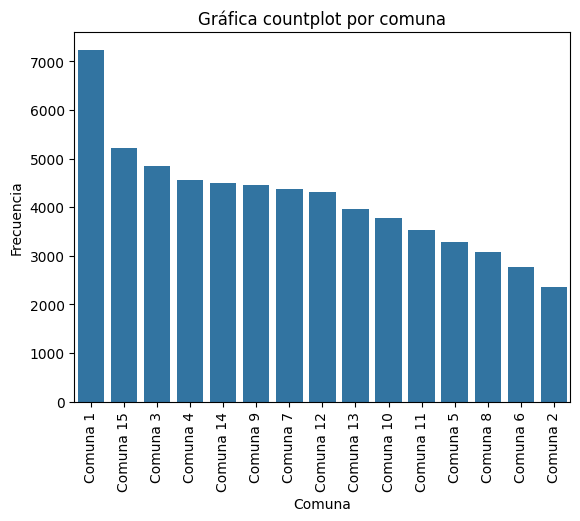

In [ ]:
#Filtrar para quedarnos solo con columnas
hechos_sin_na = hechos[hechos['comuna_siniestro'].notna()]
orden = hechos['comuna_siniestro'].value_counts().index
sns.countplot(x = hechos["comuna_siniestro"], data= hechos_sin_na, order=orden)
plt.title("Gráfica countplot por comuna")
plt.xlabel("Comuna")
plt.xticks(rotation = 90)
plt.ylabel("Frecuencia")
plt.show()

## Distribución de hechos por comuna

Una vez normalizada la columna `comuna_siniestro`, graficamos la frecuencia
de hechos por comuna para identificar las zonas de mayor concentración.

**Se excluyen los 3.552 registros sin comuna (5.4%)** para no distorsionar
la lectura con una categoría "sin dato".

## Hallazgo: comuna 1 concentra el mayor número de hechos

**Top 5 comunas por número absoluto de hechos:**
1. Comuna 1  → 7.241 hechos
2. Comuna 15 → 5.214
3. Comuna 3  → 4.858
4. Comuna 4  → 4.562
5. Comuna 14 → 4.496

**Comunas con menos hechos:**
- Comuna 2  → 2.350
- Comuna 6  → 2.772
- Comuna 8  → 3.088

**Promedio por comuna:** ~4.300 hechos (excluyendo los sin dato).

**Interpretación:**
- La Comuna 1 (Retiro, San Nicolás, Puerto Madero) tiene **más del doble**
  de hechos que la Comuna 2 (la menos afectada).
- La Comuna 15 (Chacarita, Villa Crespo, La Paternal, etc.) también destaca
  con el segundo lugar.
- El patrón sugiere que las comunas céntricas y con mayor circulación
  concentran más siniestros registrados.

**Limitación crítica:** este ranking NO está normalizado. La Comuna 1 es
el centro financiero y de transporte de la ciudad; es esperable que tenga
más accidentes simplemente porque circulan más vehículos. Sin un
denominador (tráfico, población flotante, km de vías), no podemos afirmar
que sea "la más peligrosa".

**Próximo paso:** construir el mapa geográfico con lat/lng para ver la
distribución espacial fina dentro de cada comuna.

## Mapa de calor geográfico de siniestros

Construimos un mapa de calor de densidad usando las coordenadas (lat, lng)
de los hechos. El objetivo es identificar zonas de concentración espacial
que no son visibles en el conteo por comuna (una comuna puede tener muchas
sub-zonas críticas internas).

**Método:** hexbin (mapa de hexágonos) sobre lat/lng. Cada hexágono se
colorea según la cantidad de hechos que caen dentro.

**Consideraciones:**
- Se excluyen los hechos sin coordenadas (2.379 registros, 3.6%).
- Se incluyen todos los años excepto 2020 (excluido por COVID).
- Este mapa NO está normalizado por tráfico ni población. Zonas muy
  transitadas aparecerán "calientes" por volumen, no necesariamente por
  peligrosidad relativa.

In [ ]:
#Primero nos aseguramos de que las columnas tenga el formato necesario
hechos["latitud_siniestro"] = pd.to_numeric(hechos["latitud_siniestro"], errors='coerce')
hechos["longitud_siniestro"] = pd.to_numeric(hechos["longitud_siniestro"], errors='coerce')

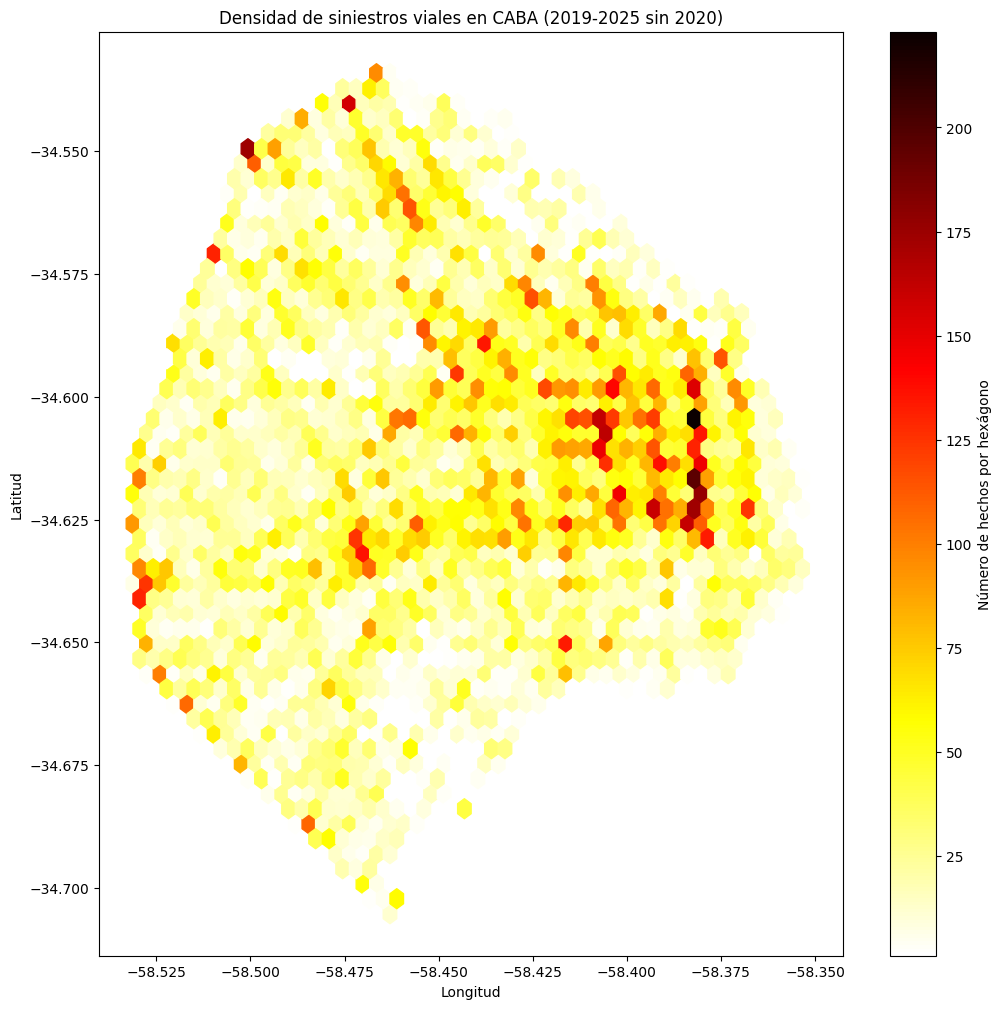

In [ ]:
hechos_mapa = hechos[hechos['comuna_siniestro'].notna() & (hechos["col_año"] !=2020)].copy()

# Convertir las columnas a tipo numérico, forzando los errores a NaN
hechos_mapa['longitud_siniestro'] = pd.to_numeric(hechos_mapa['longitud_siniestro'], errors='coerce')
hechos_mapa['latitud_siniestro'] = pd.to_numeric(hechos_mapa['latitud_siniestro'], errors='coerce')

# Eliminar filas con valores NaN en las columnas de latitud o longitud después de la conversión
hechos_mapa = hechos_mapa.dropna(subset=['longitud_siniestro', 'latitud_siniestro'])

#Crear la figura
plt.figure(figsize=(12,12))
# ¿Qué hace cada parámetro?
# - x: la columna de longitud (eje horizontal, oeste-este)
# - y: la columna de latitud (eje vertical, sur-norte)
# - gridsize: cuántos hexágonos caben en cada eje. A mayor número,
#   más detalle (pero más ruido visual). 50 es un punto medio razonable.
# - cmap='hot': escala de color tipo "calor" (negro → rojo → amarillo → blanco).
#   Los colores claros indican más hechos.
# - mincnt=1: solo colorea hexágonos que tengan al menos 1 hecho.
#   Sin esto, se colorean también las zonas vacías y el mapa se ve sucio.

plt.hexbin(
    x = hechos_mapa['longitud_siniestro'],
    y = hechos_mapa['latitud_siniestro'],
    gridsize=50,
    cmap='hot_r',
    mincnt=1
)

plt.colorbar(label="Número de hechos por hexágono")
plt.title("Densidad de siniestros viales en CABA (2019-2025 sin 2020)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

## Hallazgo: mapa de densidad geográfica

**Zonas críticas identificadas:**
1. **Franja vertical al este** (longitud -58.38 a -58.40): probablemente
   el corredor céntrico de la ciudad (Comuna 1 y adyacentes). Es la zona
   más caliente del mapa.
2. **Mancha en el norte** (latitud -34.55, longitud -58.50): probablemente
   Comuna 13/14 (Belgrano, Núñez).
3. **Corredores específicos:** el mapa muestra patrones alargados que
   sugieren concentración en avenidas principales, no distribución
   uniforme por comuna.

**Interpretación:**
- Los accidentes NO se distribuyen uniformemente por comuna. Se concentran
  en **corredores viales específicos**.
- Esto es accionable: si el gobierno quiere reducir accidentes, los
  controles deberían ubicarse en esos corredores concretos, no "en la
  Comuna 1" en general.
- Las zonas periféricas (sur y oeste) muestran densidades bajas, pero
  falta normalizar por tráfico para saber si son "más seguras" o
  simplemente "menos transitadas".

**Limitación:** el mapa no está normalizado por tráfico, población ni
extensión. Zonas muy transitadas aparecen calientes por volumen, no
necesariamente por peligrosidad relativa.

## Cierre del análisis geográfico

**Decisiones tomadas:**
- Decisión N-1 #3: los 3.552 hechos sin comuna (5.4%) se conservan con NaN
  y solo se excluyen de análisis geográficos. No se imputan.
- Decisión N-1 #4: la columna comuna_siniestro se normalizó a formato
  "Comuna N" (unificando números puros, "COMUNA N", "Comuna N").
- Decisión N-1 #5: lat/lng se convirtieron a numérico con pd.to_numeric.

**Hallazgos geográficos:**
- Comuna 1 (7.241) y Comuna 15 (5.214) son las más afectadas en números
  absolutos.
- Comuna 2 (2.350) y Comuna 6 (2.772) son las menos afectadas.
- El mapa de densidad revela corredores específicos, no distribución
  uniforme por comuna.

**Limitaciones documentadas:**
- Sin denominador (tráfico, población, km viales) no se puede concluir
  "peligrosidad relativa".
- El 5.4% sin comuna podría no ser aleatorio.

## Bloque 3: Estructura básica del DataFrame VICTIMAS

El briefing tiene 3 preguntas: ¿dónde?, ¿cuándo?, ¿qué factores comunes
tienen las víctimas? Las dos primeras ya están respondidas con HECHOS.
La tercera necesita VICTIMAS.

Antes de analizar, verificamos que VICTIMAS tenga las columnas necesarias
para responder la pregunta del briefing sobre motociclistas: tipo de
vehículo, rol, edad, sexo y gravedad.

**Este bloque responde:** ¿qué columnas existen, de qué tipo son, y cuántos
datos faltan en cada una?

In [ ]:
print(victimas.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75193 entries, 0 to 75192
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id_siniestro                 75193 non-null  object
 1   fecha_siniestro              75193 non-null  object
 2   anio_siniestro               75193 non-null  int64 
 3   modo_desplazamiento_victima  75193 non-null  object
 4   sexo_victima                 75193 non-null  object
 5   edad_victima                 75193 non-null  object
 6   GRAVEdad_victima             75193 non-null  object
 7   rol_victima                  75193 non-null  object
 8   fecha_fallecimiento_victima  703 non-null    object
dtypes: int64(1), object(8)
memory usage: 5.2+ MB
None


In [ ]:
print(victimas.describe())

       anio_siniestro
count    75193.000000
mean      2022.223412
std          2.059894
min       2019.000000
25%       2020.000000
50%       2022.000000
75%       2024.000000
max       2025.000000


In [ ]:
victimas.head(3)

,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,GRAVEdad_victima,rol_victima,fecha_fallecimiento_victima
0,LC-2019-0022650,2019-01-11,2019,BICICLETA,F,25,GRAVE,CICLISTA,NaN
1,LC-2019-0068291,2019-02-01,2019,BICICLETA,F,16,GRAVE,CICLISTA,NaN
2,LC-2019-0139186,2019-03-06,2019,BICICLETA,F,32,GRAVE,CICLISTA,NaN


## Hallazgo: estructura de VICTIMAS

El DataFrame VICTIMAS tiene 75.193 filas y 9 columnas. Es más grande que
HECHOS (65.818) porque un hecho puede tener varias víctimas (relación 1:N).

**Columnas clave para el briefing:**
- `modo_desplazamiento_victima` → permite filtrar motociclistas.
- `GRAVEdad_victima` → gravedad del siniestro.
- `fecha_fallecimiento_victima` → solo 703 no nulos → 703 fallecidos.
- `edad_victima`, `sexo_victima`, `rol_victima` → perfil de las víctimas.

**Problemas detectados:**
- `fecha_siniestro` y `edad_victima` son object (texto), requieren conversión.
- Los valores categóricos (modo, gravedad, sexo, rol) aún no han sido
  inspeccionados: hay que verificar que no tengan valores raros ("SD", " ").
- `id_siniestro` es object: habrá que verificar que coincide con `id` de HECHOS.

In [ ]:
#Revisar todos los diferentes datos escritos en la columnas: modo_desplazamiento_victima, GRAVEdad_victima, sexo_victima y rol_victima
print(victimas["modo_desplazamiento_victima"].value_counts().sort_index())
print(victimas["GRAVEdad_victima"].value_counts().sort_index())
print(victimas["sexo_victima"].value_counts().sort_index())
print(victimas["rol_victima"].value_counts().sort_index())

modo_desplazamiento_victima
AUTO                   7737
BICICLETA              6281
CAMION                  246
MIXTO                   121
MONOPATIN               209
MOTO                  22616
MOVIL                   492
OTRO                    120
PEATON                 8405
SD                    23331
TAXI                    779
TRANSPORTE PUBLICO     3880
UTILITARIO              809
auto                     37
camion                    1
monopatin                 2
moto                    126
peaton                    1
Name: count, dtype: int64
GRAVEdad_victima
GRAVE      3182
LEVE      71308
MORTAL      612
mortal       91
Name: count, dtype: int64
sexo_victima
F     19878
M     38221
SD    17094
Name: count, dtype: int64
rol_victima
CICLISTA      6281
CONDUCTOR      220
Conductor       43
PASAJERO        60
PEATON        8405
Pasajero         4
SD           60127
conductor       44
sd               9
Name: count, dtype: int64


## Bloque 4: Verificación del cruce VICTIMAS ↔ HECHOS

Antes de cualquier análisis conjunto, verificamos que las dos tablas se
pueden cruzar correctamente.

**Relación esperada:**
- `id_siniestro` (en VICTIMAS) ↔ `id` (en HECHOS)
- Un hecho puede tener varias víctimas (relación 1:N)

**Por qué es crítico:**
Si el cruce falla parcialmente, perdemos víctimas sin darnos cuenta, y
cualquier análisis posterior queda sesgado. Además, si los IDs no
coinciden en formato (mayúsculas, espacios, prefijos), el cruce puede
"fallar" sin lanzar error.

**Qué vamos a verificar:**
1. ¿Qué porcentaje de víctimas tiene un `id_siniestro` que existe en HECHOS?
2. ¿Cuántas víctimas hay por hecho en promedio?
3. ¿Cuántos hechos no tienen ninguna víctima registrada?

In [ ]:
comparacion = victimas["id_siniestro"].isin(hechos["id_siniestro"])
print("Sí existe:", comparacion.sum())
print("No existe:", (~comparacion).sum())
print("% que cruza:", comparacion.mean() * 100)

Sí existe: 75193
No existe: 0
% que cruza: 100.0


## Hallazgo: cruce VICTIMAS ↔ HECHOS exitoso

El 100% de los 75.193 `id_siniestro` de VICTIMAS existen en la columna `id`
de HECHOS. No hay pérdida de registros por integridad referencial.

**Implicación:** podemos usar merge() con confianza para combinar ambas
tablas y enriquecer el análisis de víctimas con las variables de HECHOS
(fecha, hora, comuna, lat/lng, tipo de vía).

**Pendiente:** verificar la distribución de víctimas por hecho (relación 1:N)
para saber si hay hechos con muchas víctimas (accidentes masivos) o si
todos tienen 1-2 víctimas.

In [ ]:
#Ahora hay que estandarizar los elementos visto en los demás columnas modo_desplazamiento_victima, GRAVEdad_victima y rol_victima
victimas["modo_desplazamiento_victima"] = victimas["modo_desplazamiento_victima"].str.upper()
victimas["GRAVEdad_victima"] = victimas["GRAVEdad_victima"].str.upper()
victimas["rol_victima"] = victimas["rol_victima"].str.upper()
print(victimas[["modo_desplazamiento_victima","GRAVEdad_victima","rol_victima"]].value_counts())

modo_desplazamiento_victima  GRAVEdad_victima  rol_victima
SD                           LEVE              SD             23299
MOTO                         LEVE              SD             20809
AUTO                         LEVE              SD              7401
PEATON                       LEVE              PEATON          7328
BICICLETA                    LEVE              CICLISTA        5992
TRANSPORTE PUBLICO           LEVE              SD              3790
MOTO                         GRAVE             SD              1644
PEATON                       GRAVE             PEATON           802
UTILITARIO                   LEVE              SD               773
TAXI                         LEVE              SD               763
MOVIL                        LEVE              SD               485
AUTO                         GRAVE             SD               312
PEATON                       MORTAL            PEATON           275
MOTO                         MORTAL            CONDUCTOR 

In [ ]:
print(victimas["modo_desplazamiento_victima"].value_counts())
print(victimas["GRAVEdad_victima"].value_counts())
print(victimas["rol_victima"].value_counts())

modo_desplazamiento_victima
SD                    23331
MOTO                  22742
PEATON                 8406
AUTO                   7774
BICICLETA              6281
TRANSPORTE PUBLICO     3880
UTILITARIO              809
TAXI                    779
MOVIL                   492
CAMION                  247
MONOPATIN               211
MIXTO                   121
OTRO                    120
Name: count, dtype: int64
GRAVEdad_victima
LEVE      71308
GRAVE      3182
MORTAL      703
Name: count, dtype: int64
rol_victima
SD           60136
PEATON        8405
CICLISTA      6281
CONDUCTOR      307
PASAJERO        64
Name: count, dtype: int64


## Hallazgo: normalización de categorías + integridad

Se normalizaron a mayúsculas las columnas `modo_desplazamiento_victima`,
`GRAVEdad_victima` y `rol_victima`. Ya no hay duplicados por formato.

**Estado de cada columna:**
- `GRAVEdad_victima`: sin "SD" → 71.308 LEVE, 3.182 GRAVE, 703 MORTAL.
  Integridad perfecta con `fecha_fallecimiento_victima` (703 no nulos).
- `modo_desplazamiento_victima`: 31% "SD". MOTO es la segunda categoría
  más grande (22.742, 30%).
- `sexo_victima`: 23% "SD".
- `rol_victima`: 80% "SD" → prácticamente inútil para conclusiones.

**Hallazgo clave para el briefing:**
Los motociclistas son la **primera causa de muerte vial** (289 fallecidos),
seguidos de peatones (275) y autos (61). Esto confirma la alarma del
briefing: el aumento de siniestros de moto no es solo cuantitativo,
también es el grupo con más muertes.

**Limitación:** el 31% de "SD" en modo de desplazamiento significa que
el conteo real de víctimas en moto podría ser aún mayor.

In [ ]:
#Hay que cambiar el formato de edad al correcto, pero antes de eso verificar que todos los datos sean números
print(victimas["edad_victima"].value_counts())
print(victimas["edad_victima"].nunique())

edad_victima
SD     23296
27      1668
29      1667
28      1637
30      1634
       ...  
99         1
116        1
39         1
65         1
61         1
Name: count, Length: 106, dtype: int64
106


In [ ]:
# PASO 1: Intentar convertir TODA la columna a número.
edades = pd.to_numeric(victimas["edad_victima"], errors='coerce')
numericos = sorted(edades.dropna().astype(int).unique())

# PASO 3: Separar los valores que NO se convirtieron (quedaron NaN).
no_numericos = victimas.loc[edades.isna(), 'edad_victima'].unique()

# PASO 4: Mostrar ambos resultados.
print("Valores numéricos únicos:", numericos)
print()
print("Valores no numéricos únicos:", no_numericos)
print()
print("Total numéricos:", len(numericos))
print("Total no numéricos:", len(no_numericos))

Valores numéricos únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.

## Limpieza de edad_victima

La columna `edad_victima` es de tipo `object` (texto) y contiene:
- 101 valores numéricos (0 a 116).
- 2 valores no numéricos: `'SD'` y `'sd'` (mismo significado, distinto formato).

**Decisiones tomadas:**
- Decisión N-1 #6: convertir la columna a numérico. Los valores `'SD'` y
  `'sd'` se convierten a NaN. La edad 116 se convierte a NaN por ser
  biológicamente imposible. Las edades 99 y 100 se conservan y se
  documentarán como outliers.

In [ ]:
victimas["edad_victima"] = pd.to_numeric(victimas["edad_victima"],errors='coerce')
victimas["edad_victima"] = victimas["edad_victima"].replace(116, np.nan)
print(victimas["edad_victima"].isnull().sum())

23373


## Hallazgo: edad_victima convertida a numérico

- `edad_victima` ahora es float64.
- 23.373 NaN (31.1%): incluye los 'SD'/'sd' originales + la edad 116
  (imposible) convertida a NaN.
- 68.820 edades válidas para analizar.

**Limitación:** el 31% sin edad coincide con el 31% sin modo de
desplazamiento. Probablemente son los mismos registros con datos
incompletos. Esto sugiere que la falta de datos no es aleatoria, sino
que hay un subconjunto del dataset con registro deficiente.

## Análisis de motociclistas: el núcleo del briefing

El briefing del proyecto es explícito: hay una crisis de siniestros de
motociclistas. Las dos primeras preguntas (dónde, cuándo) ya fueron
respondidas con HECHOS. Ahora respondemos la tercera: "¿qué factores
comunes tienen las víctimas?".

**Foco:** filtrar VICTIMAS por `modo_desplazamiento_victima == 'MOTO'`
y analizar:
1. Distribución de gravedad (leve, grave, mortal).
2. Distribución de edad.
3. Distribución de sexo.

**Limitación conocida:** el 31% de las víctimas tiene `modo = SD`, por lo
que el conteo real de motociclistas podría ser mayor.

In [ ]:
#PASO 1 - Conteo por modo y gravedad
#  1.1. Contar víctimas por modo_desplazamiento_victima.
conteo = victimas["modo_desplazamiento_victima"].value_counts()
#  1.2. Calcular el % de cada modo sobre el total.
pct = victimas["modo_desplazamiento_victima"].value_counts(normalize=True) * 100

#  1.3. Dentro de cada modo, contar la distribución de GRAVEdad_victima
#       (LEVE, GRAVE, MORTAL).
print(pd.crosstab(victimas["modo_desplazamiento_victima"], victimas["GRAVEdad_victima"]))
#  1.4. Calcular el % de cada gravedad dentro de cada modo.
#  → Responde: ¿qué modo concentra más víctimas? ¿Los motociclistas
#    mueren más que los peatones/autos en proporción?



GRAVEdad_victima             GRAVE   LEVE  MORTAL
modo_desplazamiento_victima                      
AUTO                           312   7401      61
BICICLETA                      235   5992      54
CAMION                           9    233       5
MIXTO                            2    119       0
MONOPATIN                       10    200       1
MOTO                          1644  20809     289
MOVIL                            4    485       3
OTRO                             4    116       0
PEATON                         803   7328     275
SD                              32  23299       0
TAXI                            15    763       1
TRANSPORTE PUBLICO              84   3790       6
UTILITARIO                      28    773       8


## Hallazgo: gravedad por modo de desplazamiento

**Tasas internas (% sobre el total de cada modo):**

| Modo | % MORTAL | % GRAVE | % LEVE |
|------|----------|---------|--------|
| PEATON | 3.27% | 9.55% | 87.2% |
| MOTO | 1.27% | 7.23% | 91.5% |
| AUTO | 0.78% | 4.01% | 95.2% |
| BICICLETA | 0.86% | 3.74% | 95.4% |
| TRANSPORTE PUBLICO | 0.15% | 2.16% | 97.7% |

**Hallazgos:**
1. En números absolutos, **MOTO lidera muertes** (289), seguido de
   PEATON (275).
2. En **tasa de mortalidad interna**, PEATON es el más letal (3.27%),
   más del doble que MOTO (1.27%).
3. MOTO y PEATON son los dos grupos con mayor gravedad combinada.
4. El problema de la moto es de **volumen**; el del peatón es de
   **letalidad por accidente**.

**Implicación para el briefing:**
Reducir accidentes de moto es urgente por volumen, pero no resuelve
por sí solo la mortalidad peatonal. Son dos problemas distintos que
requieren intervenciones distintas.

## Perfil de edad de motociclistas

Filtramos VICTIMAS por `modo_desplazamiento_victima == 'MOTO'` y agrupamos
las edades en rangos de 10 años. El objetivo es identificar si los
motociclistas accidentados se concentran en algún rango etario específico.

**Rangos elegidos:** 0-9, 10-19, 20-29, 30-39, 40-49, 50-59, 60-69,
70-79, 80+.

**Por qué decenios:** son estándar en estadísticas oficiales, fáciles de
leer y comparables con reportes de otros organismos.

**Limitación:** 31% de las víctimas no tiene edad registrada (SD).
El conteo real puede ser mayor en todos los rangos.

In [ ]:
#PASO 2 - Perfil de edad de motociclistas
#  2.1. Filtrar víctimas con modo = MOTO.
edad = victimas[victimas["modo_desplazamiento_victima"] == "MOTO"]
#  2.2. Definir rangos de edad: 0-17, 18-25, 26-35, 36-50, 51-65, 66+.
rangos = pd.cut(edad["edad_victima"],bins=[0,10,20,30,40,50,60,70,80,120])
#  2.3. Agrupar por rango y contar cuántas víctimas hay en cada uno.
#  2.4. Calcular % de cada rango sobre el total de motociclistas.
rangos.value_counts().sort_index()
#  2.5. Comparar contra peatones y autos (mismos rangos).
#  → Responde: ¿los motociclistas accidentados son mayormente jóvenes?

,count
edad_victima,
"(0, 10]",43
"(10, 20]",809
"(20, 30]",6461
"(30, 40]",4659
"(40, 50]",2641
"(50, 60]",1073
"(60, 70]",266
"(70, 80]",52
"(80, 120]",13


## Hallazgo: perfil etario del motociclista víctima

**Distribución por rango de edad (sobre 16.017 motociclistas con edad válida):**
- 20-29: 6.461 (40.4%) ← pico
- 30-39: 4.659 (29.1%)
- 40-49: 2.641 (16.5%)
- 10-19:   809 (5.1%)
- 50-59: 1.073 (6.7%)
- 60+:     331 (2.1%)
- 0-9:      43 (0.3%)

**Hallazgo clave:**
El 69.5% de los motociclistas accidentados tiene entre 20 y 39 años.
El grupo 20-29 es el más afectado con diferencia.

**Implicación para el briefing:**
Las campañas de prevención deben apuntar específicamente a jóvenes
de 20-39 años, con canales digitales (redes sociales, apps), no a
"motociclistas en general".

**Dato sensible:** 43 víctimas de 0-9 años → niños como acompañantes
en moto. Refuerza la necesidad de campañas sobre uso de casco infantil
y regulación de acompañantes.

**Limitación:** el perfil se basa en el 70% de los motociclistas (16.017
de 22.742). Los sin-edad podrían no seguir el mismo patrón.

In [ ]:
#PASO 3 - Perfil de sexo de motociclistas
#  3.1. Filtrar víctimas con modo = MOTO.
#  3.2. Contar por sexo_victima (M, F, SD).
sexo = edad["sexo_victima"].value_counts()
pct_sexo = edad["sexo_victima"].value_counts(normalize=True) * 100
#  3.3. Calcular % de cada sexo.
#  3.4. Comparar contra peatones y autos.
print(sexo)
print(pct_sexo)
#  → Responde: ¿hay diferencia de sexo en los accidentes de moto

sexo_victima
M     14740
SD     4929
F      3073
Name: count, dtype: int64
sexo_victima
M     64.814001
SD    21.673556
F     13.512444
Name: proportion, dtype: float64


## Hallazgo: perfil de sexo del motociclista víctima

**Distribución sobre 22.742 motociclistas:**
- Hombres (M): 14.740 (64.8%)
- Sin dato (SD): 4.929 (21.7%)
- Mujeres (F): 3.073 (13.5%)

**Hallazgo clave:**
Excluyendo los SD, los hombres representan el 82.8% de los motociclistas
accidentados y las mujeres el 17.2%. Es decir, casi 5 de cada 6
motociclistas accidentados son hombres.

**Implicación para el briefing:**
Las campañas de prevención deben apuntar principalmente a hombres
jóvenes (20-39 años), aunque las mujeres (3.073 víctimas) no deben
ser ignoradas.

**Limitación:** 21.7% de SD en sexo. Si los SD no son aleatorios, la
proporción real podría variar.


## Cierre del Bloque A: perfil del motociclista víctima

La moto es el modo identificado con más víctimas (22.742, 43.8% del total
sin SD). En números absolutos también lidera las muertes (289), aunque en
tasa de letalidad el peatón es más vulnerable (3.27% vs 1.27%). El perfil
típico del motociclista accidentado es hombre (82.8%), de 20-29 años (40.4%).
Los programas de prevención deberían apuntar a ese grupo específico, sin
ignorar los casos atípicos (mujeres, niños acompañantes, mayores de 60).

**Limitaciones documentadas:**
- 31% de SD en modo de desplazamiento.
- 21.7% de SD en sexo.
- 30% sin edad registrada.
- Los conteos de víctimas no equivalen a conteos de hechos (relación 1:N).

**Decisiones tomadas en este bloque:**
- Decisión N-1 #6: normalizar edad_victima a numérico (SD → NaN, 116 → NaN).
- Decisión N-1 #7: normalizar categorías a mayúsculas.
- Decisión N-1 #8: documentar 99 y 100 como outliers de edad.

## Bloque B: cruce VICTIMAS + HECHOS

Hasta ahora hemos analizado HECHOS (temporal, geográfico) y VICTIMAS (perfil)
por separado. Pero el briefing pregunta si los accidentes de moto tienen un
patrón distinto a los demás.

Para responder eso necesitamos cruzar ambas tablas: cada víctima hereda la
fecha, hora, comuna y coordenadas de su hecho correspondiente.

**Relación:** `id_siniestro` (VICTIMAS) ↔ `id` (HECHOS). Verificamos antes
que el 100% de los IDs de VICTIMAS existen en HECHOS, así que el merge
no debería perder filas.

**Qué vamos a analizar después del merge:**
1. ¿Los accidentes de moto ocurren en los mismos horarios que el total?
2. ¿Los accidentes de moto ocurren en las mismas comunas que el total?

In [ ]:
#Unir tabla de victimas con hechos
total = pd.merge(hechos[["id_siniestro","col_hora","comuna_siniestro"]], victimas, on='id_siniestro')
print(total.head(3))

      id_siniestro  col_hora comuna_siniestro fecha_siniestro  anio_siniestro  \
0  LC-2019-0000053       1.0         Comuna 8      2019-01-01            2019   
1  LC-2019-0000647      18.0        Comuna 12      2019-01-01            2019   
2  LC-2019-0000445      13.0        Comuna 11      2019-01-01            2019   

  modo_desplazamiento_victima sexo_victima  edad_victima GRAVEdad_victima  \
0                          SD            M          57.0             LEVE   
1                        MOTO            M          54.0            GRAVE   
2                          SD            F          42.0             LEVE   

  rol_victima fecha_fallecimiento_victima  
0          SD                         NaN  
1          SD                         NaN  
2          SD                         NaN  


## Hallazgo: merge VICTIMAS + HECHOS exitoso

Se hizo merge left seleccionando solo 3 columnas de HECHOS:
`id_siniestro`, `col_hora`, `comuna_siniestro`.

**Resultado:** el DataFrame cruzado conserva las 75.193 víctimas y añade
la hora y comuna del hecho correspondiente.

**Decisión:** se usó la columna `modo_desplazamiento_victima` de VICTIMAS
(no la de HECHOS), porque cada víctima tiene su propio modo individual,
mientras que HECHOS registra un solo modo por hecho.

**Nota:** el merge no añadió columnas redundantes porque seleccionamos
solo las 3 necesarias.

In [ ]:
total[total["modo_desplazamiento_victima"]=="MOTO"]["col_hora"].value_counts().sort_index()

,count
col_hora,
0.0,749
1.0,391
2.0,256
3.0,172
4.0,125
5.0,246
6.0,443
7.0,703
8.0,979


In [ ]:
total["col_hora"].value_counts().sort_index()

,count
col_hora,
0.0,2154
1.0,1144
2.0,806
3.0,637
4.0,577
5.0,938
6.0,1589
7.0,2562
8.0,3485


## Hallazgo: patrón horario de motociclistas vs total

**Comparación de distribución horaria:**
- Motos:   pico 15-18h (40.0% de sus accidentes), valle 3-5h.
- Total:   pico 15-18h (33.0% de sus accidentes), valle 3-5h.

**Hallazgo clave:**
El patrón horario de los motociclistas es MUY SIMILAR al del total de
víctimas. Ambos tienen pico en la tarde y valle en la madrugada.

**Pero hay una diferencia:** los motociclistas están
sobrerrepresentados en la tarde (40% vs 33%). Es decir, la tarde
concentra más accidentes de moto que de otros modos.

**Implicación para el briefing:**
Las intervenciones en horario vespertino (15-18h) benefician a todos
los usuarios viales, pero impactan especialmente a motociclistas.

**Limitación:** no se puede concluir que "las motos se accidentan más
de noche" — el patrón es compartido con el resto de víctimas.

In [ ]:
total[total["modo_desplazamiento_victima"]=="MOTO"]["comuna_siniestro"].value_counts().sort_index()

,count
comuna_siniestro,
Comuna 1,2047
Comuna 10,1434
Comuna 11,1298
Comuna 12,1816
Comuna 13,1321
Comuna 14,1604
Comuna 15,2040
Comuna 2,565
Comuna 3,1406


In [ ]:
total["comuna_siniestro"].value_counts().sort_index()

,count
comuna_siniestro,
Comuna 1,8128
Comuna 10,4332
Comuna 11,3985
Comuna 12,4983
Comuna 13,4421
Comuna 14,5080
Comuna 15,5841
Comuna 2,2582
Comuna 3,5413


## Hallazgo: patrón geográfico de motociclistas vs total

**Comparación por comuna (% del total de cada grupo):**
- Comuna 1: MOTO 14.6% | TOTAL 14.5% → idéntico
- Comuna 15: MOTO 14.6% | TOTAL 10.4% → +4.2 pp
- Comuna 12: MOTO 13.0% | TOTAL 8.9% → +4.1 pp
- Comuna 14: MOTO 11.5% | TOTAL 9.1% → +2.4 pp
- Comuna 2: MOTO 4.0% | TOTAL 4.6% → −0.6 pp

**Hallazgo clave:**
El patrón general es similar (Comuna 1 domina en ambos grupos), pero los
motociclistas están **sobrerrepresentados en comunas del oeste/norte**
(15, 12, 14, 10). La única comuna donde las motos están subrepresentadas
es la Comuna 2 (Recoleta).

**Interpretación:**
Los motociclistas no se distribuyen igual que el resto de víctimas. Su
patrón geográfico es más específico que el temporal.

**Implicación para el briefing:**
Si el gobierno quiere hacer operativos específicos para motos, las
comunas 15 y 12 son prioritarias más allá de lo que sugiere el patrón
general. La Comuna 1 sigue siendo prioritaria para todos.

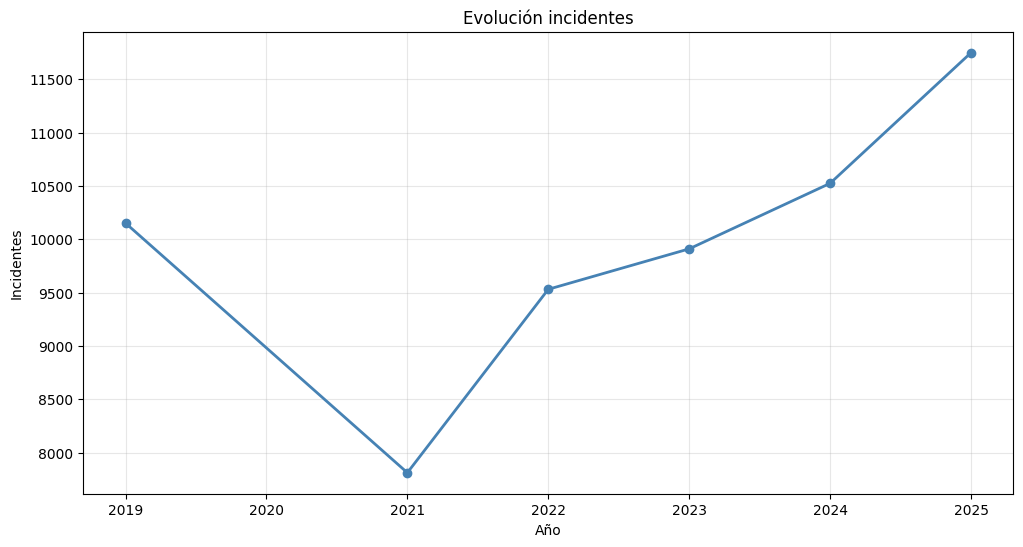

In [ ]:
#Gráfica crecimiento anual
plt.figure(figsize=(12,6))
por_año = hechos[hechos["col_año"] != 2020].groupby("col_año").size()
por_año.plot(marker='o', color='steelblue',linewidth=2)
plt.title("Evolución incidentes")
plt.xlabel("Año")
plt.ylabel("Incidentes")
plt.grid(True,alpha=0.3)
plt.show()

## Hallazgo: evolución anual de siniestros (2019-2025)

Tras la caída de 2021 (7.812 hechos, mínimo por efecto post-COVID),
los siniestros han crecido de forma sostenida:
- 2022: 9.531 (+22%)
- 2023: 9.910 (+4%)
- 2024: 10.524 (+6%)
- 2025: 11.748 (+12%)

**El nivel de 2025 supera al de 2019** (11.748 vs 10.151), lo que indica
que el problema no solo se recuperó tras la pandemia, sino que empeoró.

**Limitación:** no hay denominador (motos registradas, población, km
recorridos), por lo que no se puede concluir si el aumento se debe a
más accidentes por moto o a más motos circulando.

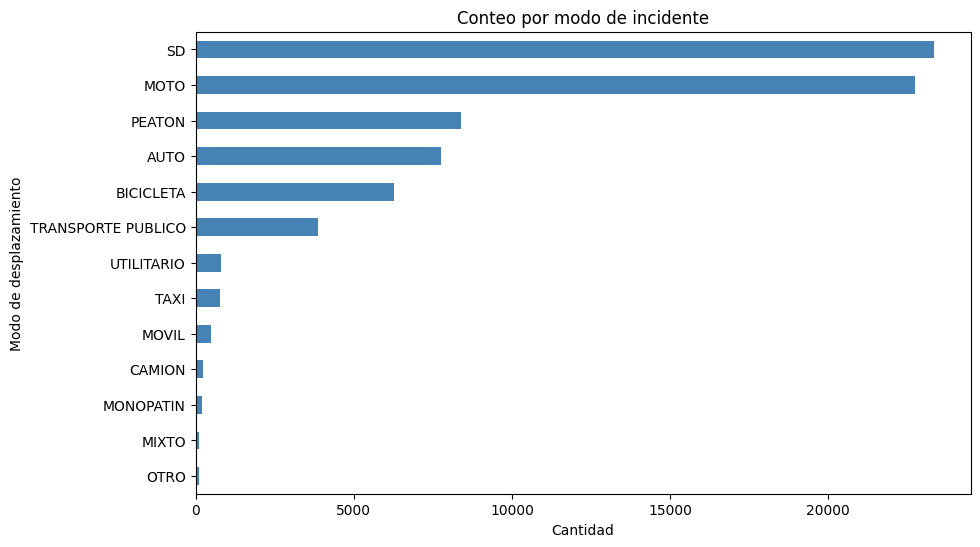

In [ ]:
por_modo = victimas["modo_desplazamiento_victima"].value_counts()
por_modo.plot(kind='barh', color='steelblue', figsize=(10, 6))
plt.gca().invert_yaxis()
plt.title('Conteo por modo de incidente')
plt.xlabel('Cantidad')
plt.ylabel('Modo de desplazamiento')
plt.show()

## Hallazgo: distribución de víctimas por modo

**Conteos:**
- SD (sin dato):    23.331 (31.0%)
- MOTO:             22.742 (30.2%)
- PEATON:            8.406 (11.2%)
- AUTO:              7.774 (10.3%)
- BICICLETA:         6.281 (8.4%)
- TRANSPORTE PUBLICO: 3.880 (5.2%)
- Otros:             ~3.779 (5.0%)

**Hallazgo clave:**
MOTO es el modo identificado con más víctimas, casi 3 veces más que
PEATON (segundo modo identificado). Si se excluye SD, MOTO representa
el 43.8% de las víctimas identificadas.

**Hallazgo secundario:**
El 31% de SD no es un detalle menor: indica un problema de registro
en el dataset que limita la precisión de los conteos por modo.

**Implicación para el briefing:**
La moto es el modo más afectado en volumen. Cualquier política de
seguridad vial debe priorizar motociclistas, y a la vez mejorar el
registro de modo de desplazamiento en el sistema.

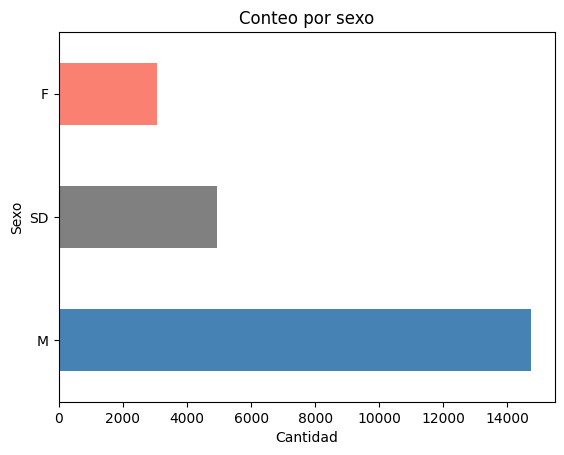

In [ ]:
sexo = victimas[victimas["modo_desplazamiento_victima"]=='MOTO']["sexo_victima"].value_counts()
sexo.plot(kind='barh',color=['steelblue','gray','salmon'])
plt.title('Conteo por sexo')
plt.xlabel('Cantidad')
plt.ylabel('Sexo')
plt.show()

## Hallazgo: sexo de motociclistas víctimas

**Distribución:**
- M:  14.740 (64.8%)
- SD:  4.929 (21.7%)
- F:   3.073 (13.5%)

**Hallazgo clave:**
Excluyendo los SD, los hombres representan el 82.8% de los motociclistas
accidentados y las mujeres el 17.2%. Es decir: casi 5 de cada 6
motociclistas accidentados son hombres.

**Implicación para el briefing:**
Las campañas de prevención deben apuntar principalmente a hombres, aunque
las 3.073 mujeres víctimas no deben ser ignoradas. El 21.7% de SD en
sexo indica que el registro tiene margen de mejora.

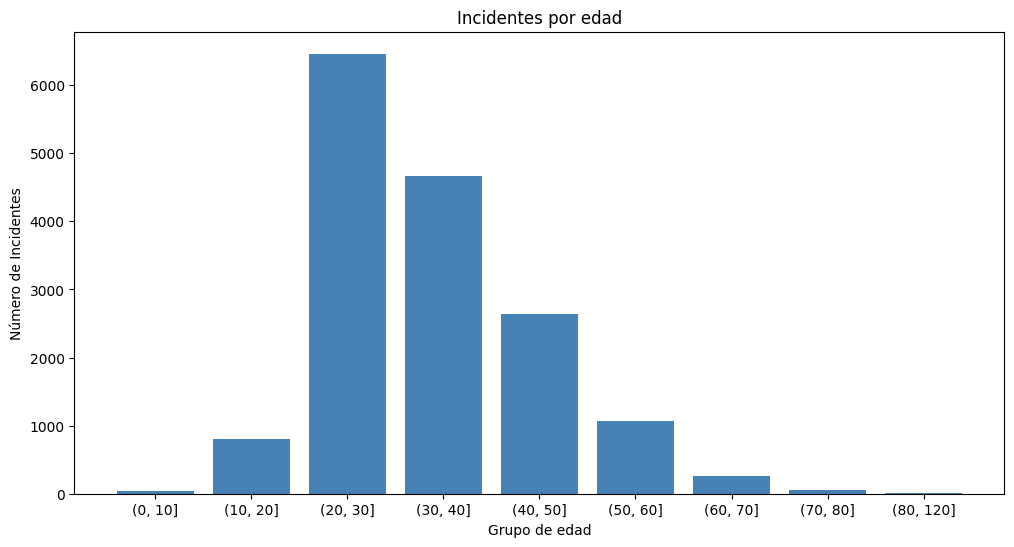

In [ ]:
#Rangos por edad
conteo = rangos.value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.bar(conteo.index.astype(str),conteo.values ,color='steelblue')
plt.title("Incidentes por edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Número de Incidentes")
plt.show()

## Hallazgo: perfil etario del motociclista víctima


**Hallazgo clave:**
El 69.5% de los motociclistas accidentados tiene entre 20 y 39 años.
El grupo 20-29 es el más afectado con diferencia (40.4% del total).

**Implicación para el briefing:**
Las campañas de prevención deben apuntar específicamente a jóvenes
de 20-39 años, con canales digitales (redes sociales, apps).

**Dato sensible:**
43 víctimas de 0-9 años → niños como acompañantes en moto. Refuerza
la necesidad de campañas sobre uso de casco infantil.

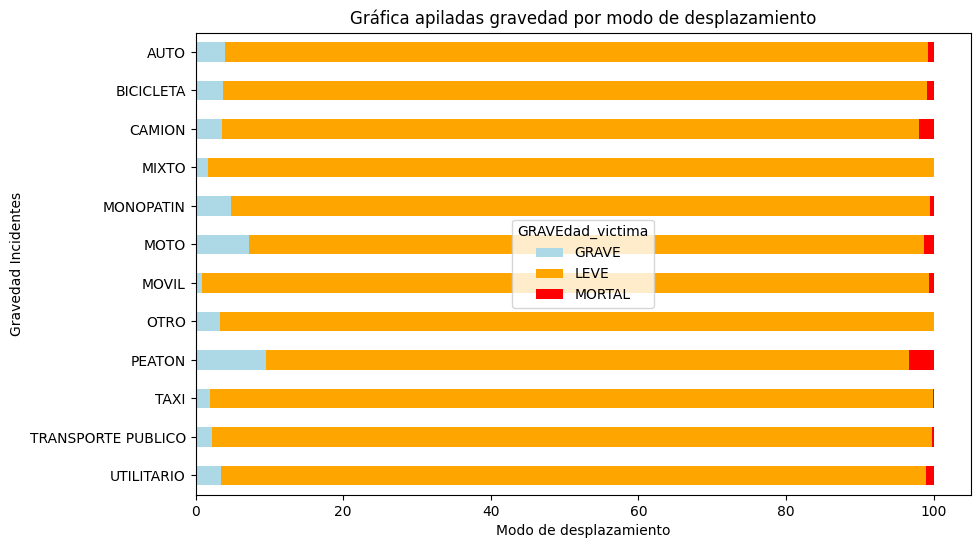

In [ ]:
apiladas= pd.crosstab(victimas["modo_desplazamiento_victima"],victimas["GRAVEdad_victima"])
apiladas_sd = apiladas.drop('SD')
apiladas_pct = apiladas_sd.div(apiladas_sd.sum(axis=1),axis=0) * 100
apiladas_pct.plot(kind='barh',stacked=True,color=['lightblue','orange','red'], figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Gráfica apiladas gravedad por modo de desplazamiento")
plt.xlabel("Modo de desplazamiento")
plt.ylabel("Gravedad Incidentes")
plt.show()

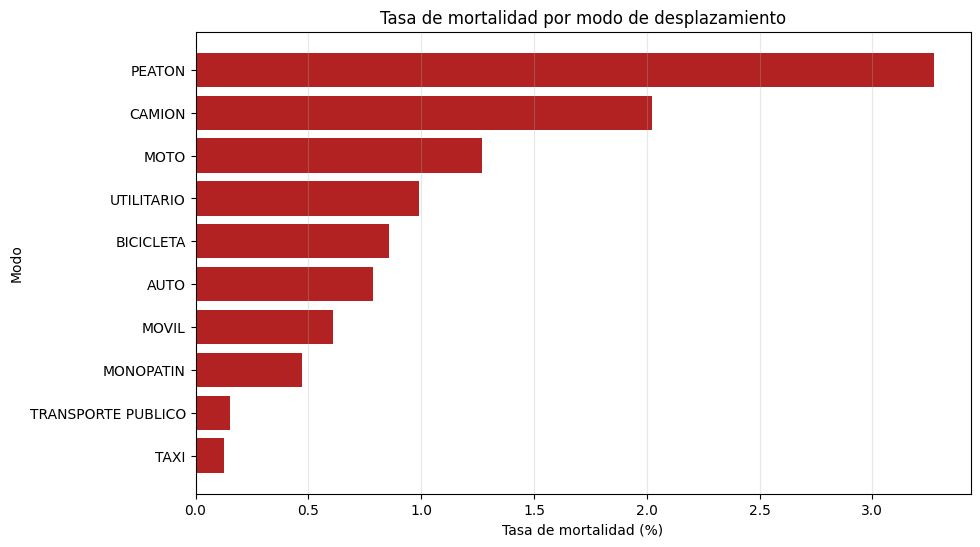

In [ ]:
tasa_mortal = apiladas_pct['MORTAL'].sort_values(ascending=True)
tasa_mortal = tasa_mortal[tasa_mortal > 0]  # filtrar los 0.0

plt.figure(figsize=(10, 6))
plt.barh(tasa_mortal.index, tasa_mortal.values, color='firebrick')  # un solo color
plt.title('Tasa de mortalidad por modo de desplazamiento')
plt.xlabel('Tasa de mortalidad (%)')
plt.ylabel('Modo')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Hallazgo: tasa de mortalidad por modo

Al normalizar por el total de víctimas de cada modo:
- PEATON: 3.27% (n=8.406)
- CAMION: 2.00% (n=247) ← n bajo, tasa inestable
- MOTO:   1.27% (n=22.742)
- AUTO:   0.78% (n=7.774)
- BICICLETA: 0.86% (n=6.281)
- TRANSPORTE PUBLICO: 0.15% (n=3.880)
- TAXI:   0.13% (n=779)

**Hallazgo clave:**
PEATON es el modo más letal por accidente (3.27%), seguido de MOTO
(1.27%). Pero CAMION aparece con 2.00% con solo 247 víctimas: la tasa
es inestable y no comparable con modos de mayor n.

**Advertencia metodológica:**
Las tasas calculadas sobre n<500 son poco confiables. En el informe,
se debe anotar el n de cada modo junto a su tasa.

**Implicación para el briefing:**
Hay dos focos prioritarios:
1. PEATON: alta letalidad por accidente.
2. MOTO: alto volumen de accidentes y muertes absolutas.

Son problemas distintos que requieren intervenciones distintas.

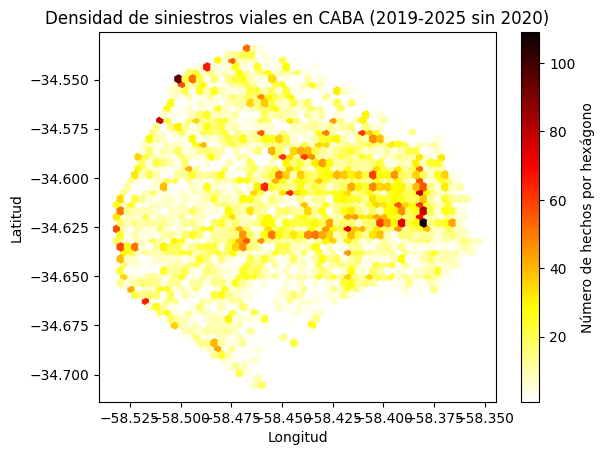

In [ ]:
#Análisis Geografico
inc_motos = hechos[hechos["modo_desplazamiento_victima"]=='MOTO']
inc_motos = inc_motos[inc_motos['latitud_siniestro'].notna() & inc_motos["col_año"] !=2020]

plt.hexbin(x=inc_motos['longitud_siniestro'],
                     y=inc_motos['latitud_siniestro'],
                     gridsize=50,
                     cmap='hot_r',
                     mincnt=1
)
plt.colorbar(label="Número de hechos por hexágono")
plt.title("Densidad de siniestros viales en CABA (2019-2025 sin 2020)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

## Hallazgo: mapa de densidad de siniestros de moto

El hexbin filtrado por MOTO revela:
- Franja vertical densa al este (corredor céntrico).
- Mancha densa en el norte (Comuna 13/14).
- Puntos rojos intensos aislados en el oeste (Comuna 15).

**Comparación con el mapa general:**
Los motociclistas comparten el patrón general (centro y norte densos),
pero con **mayor intensidad relativa en el oeste** (Comuna 15). Esto
confirma el hallazgo del análisis por comuna: la moto está
sobrerrepresentada en comunas del oeste/norte.

**Advertencia:**
La escala de color de este mapa (máx ~100) no es directamente comparable
con el mapa general (máx ~200). Si se presentan juntos en el informe,
se debe usar la misma escala o anotar la diferencia.

## Resumen ejecutivo (versión final)

El estudio de 65.818 siniestros entre 2019 y 2025 (omitiendo 2020) muestra
un incremento constante del 50% de 2021 a 2025. Las motocicletas concentran
el mayor número de afectados (43.8%), mientras que las víctimas peatonales
presentan la mayor letalidad por suceso (3.27%). Las víctimas en moto suelen
ser varones (82.8%) de 20 a 29 años (40.4%), especialmente entre las 15:00
y las 18:00 horas en las comunas 1, 15 y 12. Dado que el 31% carece de modo
de transporte registrado, el conteo real de motociclistas podría ser superior.

### Conclusiones y acciones
1. **Focalización operativa:** Desplegar controles en las comunas 1, 15 y 12
   durante la franja vespertina de 15:00 a 18:00 horas.
2. **Enfoque preventivo:** Diseñar campañas orientadas específicamente a
   conductores varones jóvenes de entre 20 y 29 años.
3. **Seguridad vial:** Intensificar la fiscalización del uso de casco y
   elementos de protección, considerando que las motos acumulan 289 muertes
   absolutas.

# Registro de decisiones del Proyecto N-1

## Decisiones metodológicas

**Decisión N-1 #1:** No se imputan los 81 valores NaT en `fecha_hora`.
Se conservan con NaT y solo se excluyen del análisis por hora.
*Motivo:* inventar la hora sería introducir datos falsos en un informe oficial.

**Decisión N-1 #2:** Se excluye el año 2020 del análisis principal por
ser un año atípico (COVID-19).
*Motivo:* el confinamiento alteró radicalmente la movilidad, haciendo 2020
no comparable con el resto. Imputarlo sería inventar una realidad que no
existió.

**Decisión N-1 #3:** Los 3.552 hechos sin comuna (5.4%) se conservan como
NaN y solo se excluyen del análisis geográfico.
*Motivo:* conservar los hechos permite usarlos en análisis no geográficos
(gravedad, modo, edad) sin perder información.

**Decisión N-1 #4:** La columna `comuna_siniestro` se normalizó a formato
"Comuna N", unificando números puros (1, 2), "COMUNA N" y "Comuna N".
*Motivo:* sin normalizar, cada formato se trataba como categoría distinta
y rompía los agrupamientos.

**Decisión N-1 #5:** Las columnas `latitud_siniestro` y `longitud_siniestro`
se convirtieron de string a numérico con `pd.to_numeric(errors='coerce')`.
*Motivo:* estaban como texto y `plt.hexbin` requiere valores numéricos.

**Decisión N-1 #6:** La columna `edad_victima` se convirtió a numérico.
Los valores `'SD'` y `'sd'` se convirtieron a NaN. La edad 116 se convirtió
a NaN por ser biológicamente imposible.
*Motivo:* sin conversión, no se pueden calcular promedios ni agrupar por rangos.

**Decisión N-1 #7:** Se normalizaron a mayúsculas las columnas categóricas
`modo_desplazamiento_victima`, `GRAVEdad_victima` y `rol_victima`.
*Motivo:* mismo problema que comuna: formatos duplicados rompían filtros.

**Decisión N-1 #8:** Las edades 99 y 100 se conservan como outliers.
*Motivo:* son improbables pero posibles. Se documentan, no se eliminan.

## Limitaciones del análisis

- **31% sin modo de desplazamiento registrado** (23.331 víctimas). El conteo
  real de motociclistas podría ser mayor.
- **21.7% sin sexo registrado** en motociclistas.
- **30% sin edad registrada** en motociclistas.
- **5.4% sin comuna** en hechos (3.552 registros).
- **80% sin rol registrado** en víctimas → `rol_victima` es prácticamente
  inutilizable para conclusiones.
- **Sin denominador** (motos registradas, población, tráfico) para
  normalizar tasas. No se puede concluir "peligrosidad relativa" entre comunas.
- **No hay datos de exposición** que expliquen si el aumento de accidentes
  se debe a más motos o a más riesgo por moto.

## Entregables generados

1. Análisis temporal (hora, día, mes, año, serie temporal, heatmap).
2. Análisis geográfico (comunas, mapa hexbin general y por modo).
3. Perfil de víctimas (modo, gravedad, edad, sexo).
4. Cruce VICTIMAS + HECHOS (horario y comuna por modo).
5. 7 visualizaciones prioritarias + descriptivas de contexto.
6. Resumen ejecutivo de 5 líneas + 3 conclusiones accionables.